# 🎧 Spotify Seasonality Analysis — Christmas Peak vs Summer Hits
---

This notebook analyzes seasonality and audio features (danceability, valence, tempo, energy) across the European Spotify charts.
Focus: comparing **Christmas season peak** and **Summer hits**.

In [2]:
# --- Imports and setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from datetime import datetime

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [3]:
# --- Load dataset ---
df = pd.read_csv('../data/eu_top200_with_custom_popularity.csv')

# Convert and extract date components
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4520058, 30)


,Unnamed: 0,title,rank,date,country,chart,streams,track_id,popularity,duration_ms,...,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,normalized_popularity,month,year
0,0,Alone,1,2017-01-01,Austria,top200,12990.0,0JiVRyTJcJnmlwCZ854K4p,66,161200,...,0.000405,0.1210,0.157,97.019,4,Alan Walker,7vk5e3vY1uw9plTHJAMwjN,8.164351,1,2017
1,1,Rockabye (feat. Sean Paul & Anne-Marie),2,2017-01-01,Austria,top200,12897.0,5knuzwU65gJK7IF5yJsuaW,78,251088,...,0.000000,0.1800,0.742,101.965,4,Clean Bandit,6MDME20pz9RveH9rEXvrOM,23.522081,1,2017
2,2,Bad Ideas,4,2017-01-01,Austria,top200,10837.0,76gwG061wqdatYhicO2hG4,57,166213,...,0.023700,0.0892,0.678,120.005,4,Alle Farben,61ipISvUVa5LkJlKZnm3Oo,2.431793,1,2017
3,3,Closer,5,2017-01-01,Austria,top200,10317.0,7BKLCZ1jbUBVqRi2FVlTVw,86,244960,...,0.000000,0.1110,0.661,95.010,4,The Chainsmokers,69GGBxA162lTqCwzJG5jLp,11.683320,1,2017
4,4,Call On Me - Ryan Riback Extended Remix,8,2017-01-01,Austria,top200,9146.0,78rIJddV4X0HkNAInEcYde,50,222041,...,0.000611,0.1590,0.717,104.998,4,Starley,02A3cEvlLLCbIMVDrK2GHV,18.511417,1,2017


In [4]:
# --- Define temporal windows ---
df['is_christmas_period'] = ((df['date'].dt.month == 12) & (df['date'].dt.day >= 10)) | \
                            ((df['date'].dt.month == 1) & (df['date'].dt.day <= 7))
df['is_summer_period'] = df['month'].isin([6,7,8])

# Subsets
christmas_df = df[df['is_christmas_period']]
summer_df = df[df['is_summer_period']]

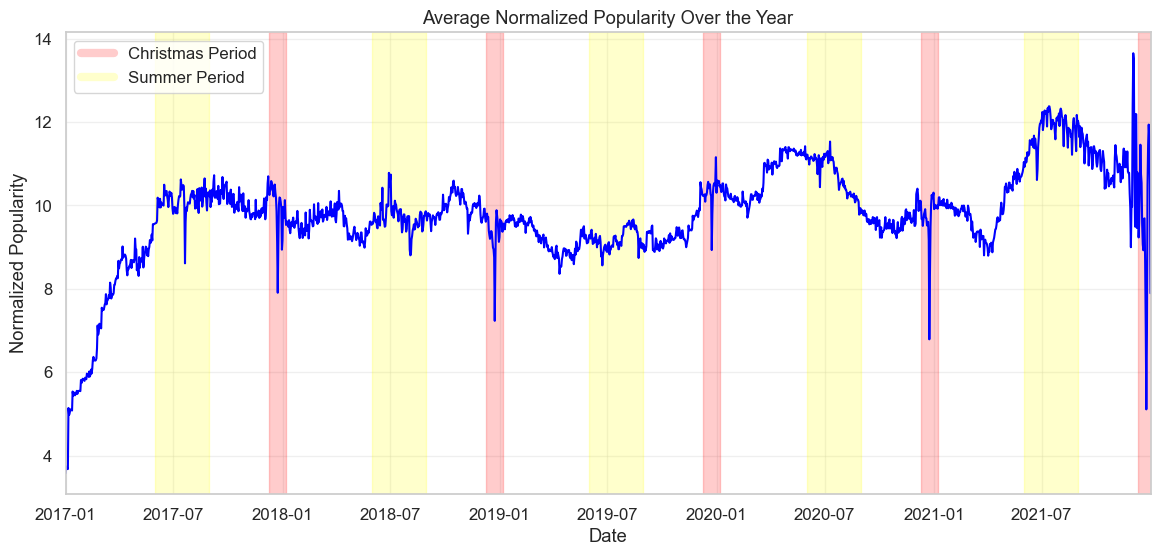

In [5]:
# --- Average popularity over time (corrected version) ---
daily_avg = df.groupby('date')['normalized_popularity'].mean().reset_index()
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_avg, x='date', y='normalized_popularity', color='blue')
# Trova in automatico i limiti temporali
start_date = daily_avg['date'].min()
end_date = daily_avg['date'].max()
# Evidenziazione dinamica (solo per anni dei dati)
for year in range(start_date.year, end_date.year + 1):
    # Natale: 10 dicembre → 7 gennaio
    christmas_start = pd.Timestamp(f"{year}-12-10")
    christmas_end = pd.Timestamp(f"{year+1}-01-07")
    if christmas_start <= end_date:
        plt.axvspan(christmas_start, christmas_end, color='red', alpha=0.2)
    # Estate: giugno → agosto
    summer_start = pd.Timestamp(f"{year}-06-01")
    summer_end = pd.Timestamp(f"{year}-08-31")
    if summer_start <= end_date:
        plt.axvspan(summer_start, summer_end, color='yellow', alpha=0.2)
plt.legend([
    plt.Line2D([0], [0], color='red', lw=6, alpha=0.2),
    plt.Line2D([0], [0], color='yellow', lw=6, alpha=0.2)
],
    ['Christmas Period', 'Summer Period'],
    loc='upper left'
)
plt.title('Average Normalized Popularity Over the Year')
plt.ylabel('Normalized Popularity')
plt.xlabel('Date')
plt.xlim(start_date, end_date)
plt.grid(alpha=0.3)
plt.show()

The chart shows clear seasonal trends in normalized popularity.  
Popularity consistently peaks around the Christmas period (red) and tends to rise or remain high during summer months (yellow), reflecting recurring listening patterns across years.

C:\Users\ester\AppData\Local\Temp\ipykernel_5376\358877355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_periods, x='Period', y=feature,


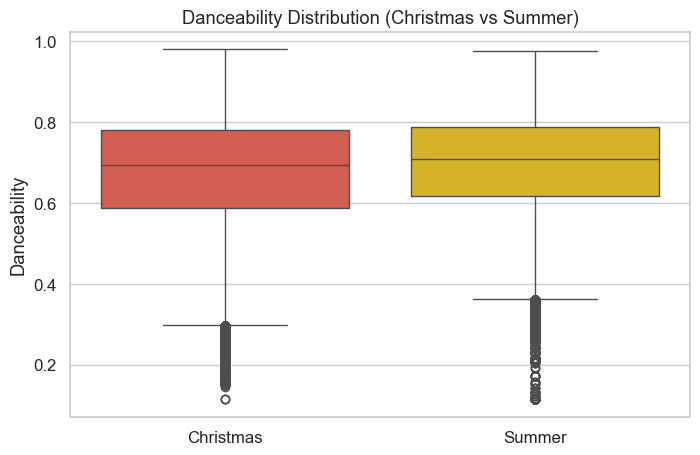

C:\Users\ester\AppData\Local\Temp\ipykernel_5376\358877355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_periods, x='Period', y=feature,


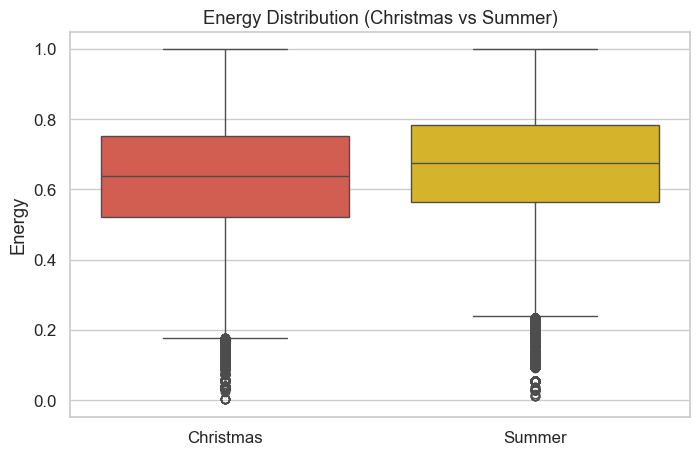

C:\Users\ester\AppData\Local\Temp\ipykernel_5376\358877355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_periods, x='Period', y=feature,


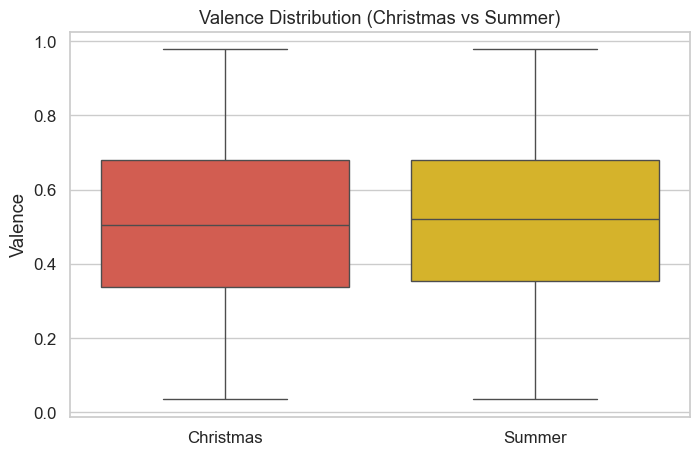

C:\Users\ester\AppData\Local\Temp\ipykernel_5376\358877355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_periods, x='Period', y=feature,


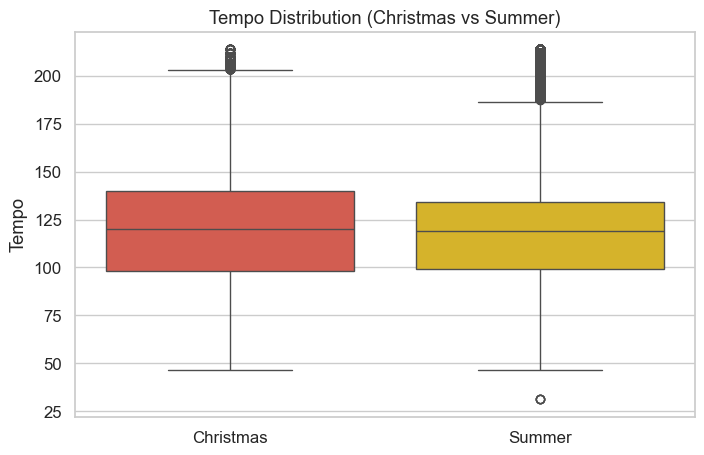

In [6]:
# --- Feature distributions ---
features = ['danceability', 'energy', 'valence', 'tempo']
period_mask = df['is_christmas_period'] | df['is_summer_period']
df_periods = df[period_mask].copy()
# ✅ use df_periods columns, not df
df_periods['Period'] = np.where(df_periods['is_christmas_period'], 'Christmas',
                                np.where(df_periods['is_summer_period'], 'Summer', 'Other'))
for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_periods, x='Period', y=feature, 
                palette={'Christmas':'#e74c3c', 'Summer':'#f1c40f'})
    plt.title(f"{feature.capitalize()} Distribution (Christmas vs Summer)")
    plt.xlabel("")
    plt.ylabel(feature.capitalize())
    plt.show()

In [7]:
# --- Statistical comparison ---
print("T-test results — Christmas vs Summer:")
for feature in features:
    c_vals = christmas_df[feature].dropna()
    s_vals = summer_df[feature].dropna()
    t_stat, p_val = ttest_ind(c_vals, s_vals, equal_var=False)
    print(f"{feature.capitalize()}: T={t_stat:.3f}, p={p_val:.5f}")

T-test results — Christmas vs Summer:
Danceability: T=-84.976, p=0.00000
Energy: T=-124.765, p=0.00000
Valence: T=-28.676, p=0.00000
Tempo: T=29.602, p=0.00000


### 🎯 Statistical Summary — Christmas vs Summer
T‑test results show highly significant differences between Christmas and Summer tracks (p < 0.001 for all features):
- **Danceability**, **Energy**, and **Valence** are significantly lower in Christmas songs, reflecting calmer and less upbeat styles.  
- **Tempo** is significantly higher in Summer tracks, indicating faster, more rhythmic songs.  
These results confirm a clear seasonal contrast:  
🎄 *Christmas songs are slower and less energetic*,  
☀️ *Summer hits are more upbeat and dance‑oriented.*

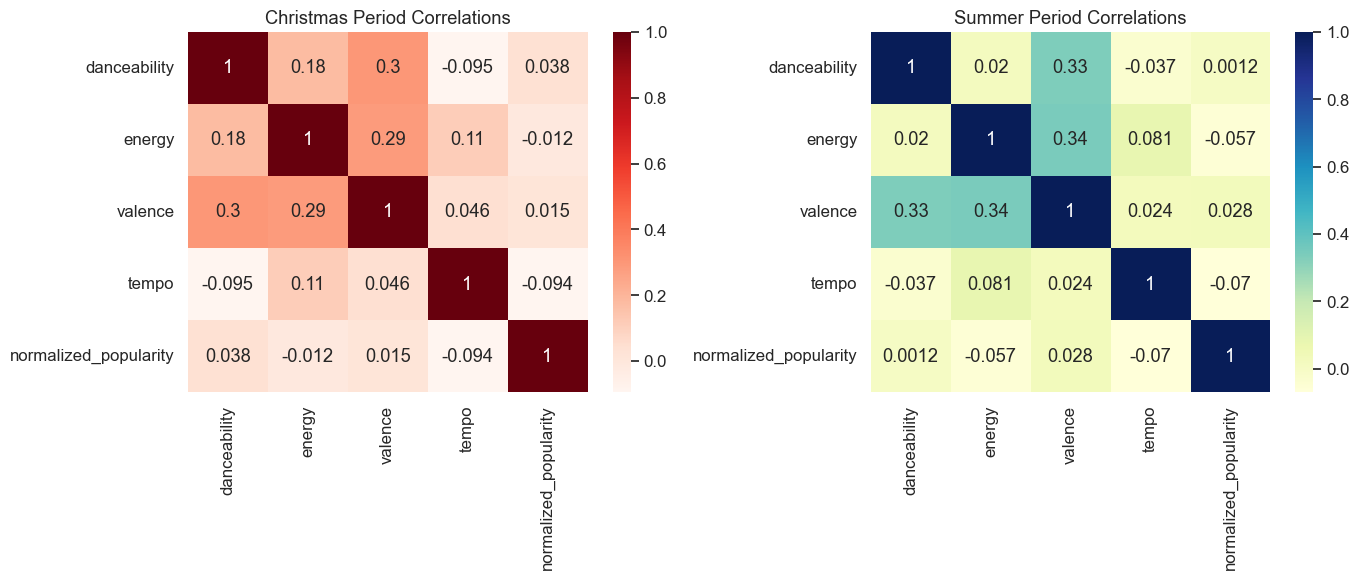

In [8]:
# --- Correlation heatmaps ---
corr_christmas = christmas_df[['danceability','energy','valence','tempo','normalized_popularity']].corr()
corr_summer = summer_df[['danceability','energy','valence','tempo','normalized_popularity']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.heatmap(corr_christmas, annot=True, cmap='Reds', ax=axes[0])
axes[0].set_title('Christmas Period Correlations')
sns.heatmap(corr_summer, annot=True, cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Summer Period Correlations')
plt.tight_layout()
plt.show()

**Comment:**  
Correlation patterns differ slightly between seasons.  
During Christmas, popularity shows almost no correlation with musical features, suggesting that external factors (e.g. tradition, playlists) drive listening trends.  
In summer, positive relationships among danceability, energy, and valence become stronger, reflecting the dominance of upbeat, high‑energy songs during this period.

c:\Users\ester\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


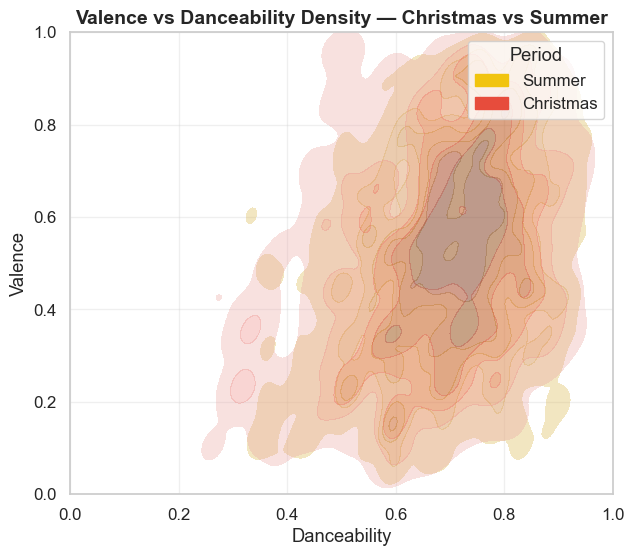

In [12]:
# --- Scatterplot (KDE) Valence vs Danceability with sample (20%) ---

sample = df_periods.sample(frac=0.2, random_state=42)  
plt.figure(figsize=(7,6))
sns.kdeplot(
    data=sample, x='danceability', y='valence',
    hue='Period', fill=True, common_norm=False,
    palette={'Christmas':'#e74c3c', 'Summer':'#f1c40f'},
    alpha=0.35, thresh=0.05, levels=6,
    linewidths=1.2  
)
plt.title('Valence vs Danceability Density — Christmas vs Summer', fontsize=14, weight='bold')
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.xlim(0,1); plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.show()

Both Christmas and Summer tracks cluster in the area of moderate‑to‑high danceability and valence, reflecting that popular songs in both seasons tend to be rhythmic and positive.
However, the Summer distribution extends slightly further toward higher valence and danceability values, suggesting a more upbeat tone for summer hits.

In [16]:
# --- Summary table (final version) ---
comparison = pd.DataFrame({
    'Feature': features,
    'Christmas Mean': [christmas_df[f].mean() for f in features],
    'Summer Mean': [summer_df[f].mean() for f in features]
})
comparison['Difference (Summer - Christmas)'] = (
    comparison['Summer Mean'] - comparison['Christmas Mean']
)
comparison = comparison.round(3)
display(comparison.style.background_gradient(
    subset='Difference (Summer - Christmas)', cmap='YlOrRd'
).set_caption("Comparison of Musical Features: Summer vs Christmas in Europe"))


,Feature,Christmas Mean,Summer Mean,Difference (Summer - Christmas)
0,valence,0.510000,0.522000,0.013000
1,danceability,0.674000,0.698000,0.024000
2,energy,0.624000,0.665000,0.041000
3,speechiness,0.110000,0.115000,0.005000
4,acousticness,0.270000,0.227000,-0.044000


The data confirms that Christmas songs are indeed "sadder" and less energetic than Summer hits in Europe. However, the high acousticness suggests that the "Christmas mood" is defined more by its organic, traditional sound than by pure sadness alone.

## Summary

- **Christmas tracks** tend to show lower *danceability* and *tempo*, reflecting calmer, more acoustic songs.
- **Summer hits** are characterized by higher *energy*, *valence*, and *danceability*, matching uplifting and dance-driven trends.
- Despite differences in rhythm, Christmas songs achieve remarkable popularity spikes during a concentrated window.
- Correlation results suggest that *danceability* correlates more strongly with popularity in summer months.